In [22]:
import os
import pandas as pd
import numpy as np
import glob
import sys
import io
from contextlib import redirect_stdout, redirect_stderr
from typing import Dict, List, Any, TypedDict
from dotenv import load_dotenv
from langgraph.graph import StateGraph, END
import google.generativeai as genai
from langchain_google_genai import ChatGoogleGenerativeAI

In [2]:
# Load environment variables
load_dotenv()

# Configure Gemini
genai.configure(api_key=os.getenv('GEMINI_API_KEY'))

In [3]:
class RootCauseState(TypedDict):
    question: str
    current_findings: str
    iteration_count: int
    max_iterations: int
    root_cause_found: bool
    root_cause: str
    primary_data_insights: List[str]
    secondary_data_insights: List[str]
    analysis_path: List[str]
    executed_code_results: List[str]  # New: Store code execution results

In [14]:
class RootCauseAgent:
    def __init__(self):
        self.llm = ChatGoogleGenerativeAI(
            model="gemini-2.5-flash",
            google_api_key=os.getenv('GEMINI_API_KEY'),
            temperature=0.1
        )
        self.metrics_path = "metrics/"
        self.synthetic_path = "synthetic_data/"
        self.primary_data = {}
        self.secondary_data = {}
        
    def load_primary_data(self) -> Dict[str, pd.DataFrame]:
        """Load all CSV files from metrics folder"""
        if not self.primary_data:
            csv_files = glob.glob(os.path.join(self.metrics_path, "*.csv"))
            for file in csv_files:
                filename = os.path.basename(file).replace('.csv', '')
                try:
                    self.primary_data[filename] = pd.read_csv(file)
                    print(f"Loaded primary data: {filename} with shape {self.primary_data[filename].shape}")
                except Exception as e:
                    print(f"Error loading {file}: {e}")
        return self.primary_data
    
    def load_secondary_data(self) -> Dict[str, pd.DataFrame]:
        """Load all CSV files from synthetic_data folder"""
        if not self.secondary_data:
            csv_files = glob.glob(os.path.join(self.synthetic_path, "*.csv"))
            for file in csv_files:
                filename = os.path.basename(file).replace('.csv', '')
                try:
                    self.secondary_data[filename] = pd.read_csv(file)
                    print(f"Loaded secondary data: {filename} with shape {self.secondary_data[filename].shape}")
                except Exception as e:
                    print(f"Error loading {file}: {e}")
        return self.secondary_data

    def execute_pandas_code(self, code: str, data_context: Dict[str, pd.DataFrame]) -> str:
        """Safely execute pandas code and return results"""
        # Fixed: Direct import instead of dynamic __import__
        safe_globals = {
            'pd': pd,
            'pandas': pd,
            'np': np,  # Direct reference to imported numpy
            'numpy': np,  # Direct reference to imported numpy
            '__builtins__': {
                'len': len, 'str': str, 'int': int, 'float': float, 
                'list': list, 'dict': dict, 'tuple': tuple, 'set': set,
                'min': min, 'max': max, 'sum': sum, 'abs': abs,
                'round': round, 'sorted': sorted, 'enumerate': enumerate,
                'zip': zip, 'range': range, 'print': print
            }
        }
        
        # Add dataframes to execution context
        safe_globals.update(data_context)
        
        stdout_capture = io.StringIO()
        stderr_capture = io.StringIO()
        
        try:
            with redirect_stdout(stdout_capture), redirect_stderr(stderr_capture):
                exec(code, safe_globals)
            
            output = stdout_capture.getvalue()
            error = stderr_capture.getvalue()
            
            if error:
                return f"Error executing code:\n{error}"
            elif output:
                return f"Code execution results:\n{output}"
            else:
                return "Code executed successfully (no output generated)"
                
        except Exception as e:
            return f"Execution error: {str(e)}"

In [15]:
def identify_pattern_node(state: RootCauseState) -> RootCauseState:
    """First node: Identify patterns and generate initial analysis code"""
    agent = RootCauseAgent()
    primary_data = agent.load_primary_data()

    # Get data summaries for pattern identification
    data_summaries = {}
    for name, df in primary_data.items():
        data_summaries[name] = {
            'columns': list(df.columns),
            'shape': df.shape,
            'dtypes': df.dtypes.to_dict(),
            'sample_data': df.head(2).to_dict() if not df.empty else {}
        }

    pattern_prompt = f"""
    Question: {state['question']}

    Available primary data sources:
    {data_summaries}

    Based on the question and available data sources:
    1. Identify what type of analysis pattern this question follows
    2. Which primary data sources are most relevant
    3. Generate specific pandas code to explore the data related to the question

    Please provide your analysis AND generate Python/pandas code to investigate the question.
    Format your response as:

    ANALYSIS:
    [Your analysis here]

    CODE:
    ```
    # Your pandas code here
    # Use dataframe variable names: {list(primary_data.keys())}
    # Always print results using print() statements
    ```
    """

    response = agent.llm.invoke(pattern_prompt)
    response_content = getattr(response, 'content', str(response))

    # Extract and execute code if present
    code_results = ""
    if "```" in response_content:
        code_block_start = response_content.find("```python")
        if code_block_start == -1:
            code_block_start = response_content.find("```")
            fence_length = 3
        else:
            fence_length = len("```python")
        if code_block_start != -1:
            code_start = code_block_start + fence_length
            code_end = response_content.find("```", code_start)
            if code_end != -1:
                code = response_content[code_start:code_end].strip()
                # Execute the code
                code_results = agent.execute_pandas_code(code, primary_data)
                state['executed_code_results'].append(
                    f"Pattern Analysis Code Results:\n{code_results}"
                )

    state['current_findings'] = response_content + "\n\nEXECUTION RESULTS:\n" + code_results
    state['analysis_path'].append("Pattern identified and code executed")
    state['iteration_count'] = 1

    return state

In [16]:
def analyze_primary_data_node(state: RootCauseState) -> RootCauseState:
    """Analyze primary data with LLM-generated pandas code"""
    agent = RootCauseAgent()
    primary_data = agent.load_primary_data()
    
    primary_analysis_prompt = f"""
    Question: {state['question']}
    Previous findings: {state['current_findings']}
    
    Available primary datasets and their structures:
    {[(name, df.shape, list(df.columns)) for name, df in primary_data.items()]}
    
    Based on the question and previous findings:
    1. Generate specific pandas code to dig deeper into the primary data
    2. Focus on finding patterns, anomalies, or trends related to the question
    3. Create visualizations or summary statistics that help answer the question
    
    Format your response as:
    
    ANALYSIS:
    [Your detailed analysis and insights]
    
    CODE:
    ```python
    # Your pandas code here for deeper analysis
    # Available dataframes: {list(primary_data.keys())}
    # Always print results and findings
    ```
    """
    
    response = agent.llm.invoke(primary_analysis_prompt)
    response_content = response.content
    
    code_results = ""
    if "```python" in response_content:
        code_start = response_content.find("```python") + 9
        code_end = response_content.find("```", code_start)
        if code_end != -1:
            code = response_content[code_start:code_end].strip()
            code_results = agent.execute_pandas_code(code, primary_data)
            state['executed_code_results'].append(f"Primary Analysis Code Results:\n{code_results}")
    
    combined_findings = response_content + "\n\nCODE EXECUTION RESULTS:\n" + code_results
    state['primary_data_insights'].append(combined_findings)
    state['current_findings'] = combined_findings
    state['analysis_path'].append("Primary data analyzed with code execution")
    
    return state


In [17]:
def analyze_secondary_data_node(state: RootCauseState) -> RootCauseState:
    """Analyze secondary synthetic data with LLM-generated pandas code"""
    agent = RootCauseAgent()
    primary_data = agent.load_primary_data()
    secondary_data = agent.load_secondary_data()
    
    all_data = {**primary_data, **secondary_data}
    
    secondary_analysis_prompt = f"""
    Question: {state['question']}
    Primary findings: {state['primary_data_insights'][-1] if state['primary_data_insights'] else 'None'}
    Current iteration: {state['iteration_count']}
    Previous code results: {state['executed_code_results'][-1] if state['executed_code_results'] else 'None'}
    
    Available datasets (primary + secondary):
    {[(name, df.shape, list(df.columns)) for name, df in all_data.items()]}
    
    Based on primary findings, generate pandas code to:
    1. Correlate primary and secondary data
    2. Find root causes by analyzing relationships between datasets
    3. Look for deeper patterns that explain the findings from primary analysis
    4. Generate specific insights that answer the original question
    
    Format your response as:
    
    ANALYSIS:
    [Your root cause analysis connecting primary and secondary data]
    
    CODE:
    ```
    # Your pandas code for root cause analysis
    # Available dataframes: {list(all_data.keys())}
    # Focus on correlations, joins, and cross-dataset analysis
    # Always print your findings
    ```
    """
    
    response = agent.llm.invoke(secondary_analysis_prompt)
    response_content = response.content
    
    code_results = ""
    if "```python" in response_content:
        code_start = response_content.find("```python") + 9
        code_end = response_content.find("```", code_start)
        if code_end != -1:
            code = response_content[code_start:code_end].strip()
            code_results = agent.execute_pandas_code(code, all_data)
            state['executed_code_results'].append(f"Secondary Analysis Code Results (Iteration {state['iteration_count']}):\n{code_results}")
    
    combined_findings = response_content + "\n\nCODE EXECUTION RESULTS:\n" + code_results
    state['secondary_data_insights'].append(combined_findings)
    state['current_findings'] = combined_findings
    state['analysis_path'].append(f"Secondary data analyzed with code execution (iteration {state['iteration_count']})")
    
    return state


In [18]:
def root_cause_evaluation_node(state: RootCauseState) -> RootCauseState:
    """Evaluate if we've found the root cause based on code execution results"""
    agent = RootCauseAgent()
    
    evaluation_prompt = f"""
    Original question: {state['question']}
    Current iteration: {state['iteration_count']}
    Analysis path: {' -> '.join(state['analysis_path'])}
    
    All code execution results:
    {chr(10).join(state['executed_code_results'])}
    
    Primary insights: {state['primary_data_insights']}
    Secondary insights: {state['secondary_data_insights']}
    
    Based on all the data analysis and code execution results:
    1. Have we identified a clear, data-driven root cause for the question?
    2. Are the computational results sufficient to provide a definitive answer?
    3. Or do we need additional analysis iterations?
    
    Respond with either:
    - "ROOT_CAUSE_FOUND: [detailed root cause with supporting data evidence]"
    - "CONTINUE_ANALYSIS: [specific aspects that need further investigation]"
    """
    
    response = agent.llm.invoke(evaluation_prompt)
    response_text = response.content
    
    if "ROOT_CAUSE_FOUND:" in response_text:
        state['root_cause_found'] = True
        state['root_cause'] = response_text.replace("ROOT_CAUSE_FOUND:", "").strip()
    else:
        state['root_cause_found'] = False
        state['current_findings'] = response_text
    
    state['iteration_count'] += 1
    return state

In [19]:
def should_continue(state: RootCauseState) -> str:
    """Decision function to determine if we should continue or end"""
    if state['root_cause_found']:
        return "end"
    elif state['iteration_count'] >= state['max_iterations']:
        return "end"
    else:
        return "continue"


In [20]:
def create_root_cause_workflow():
    """Build the LangGraph workflow"""
    workflow = StateGraph(RootCauseState)
    
    workflow.add_node("identify_pattern", identify_pattern_node)
    workflow.add_node("analyze_primary", analyze_primary_data_node)
    workflow.add_node("analyze_secondary", analyze_secondary_data_node)
    workflow.add_node("evaluate_root_cause", root_cause_evaluation_node)
    
    workflow.set_entry_point("identify_pattern")
    workflow.add_edge("identify_pattern", "analyze_primary")
    workflow.add_edge("analyze_primary", "analyze_secondary")
    workflow.add_edge("analyze_secondary", "evaluate_root_cause")
    
    workflow.add_conditional_edges(
        "evaluate_root_cause",
        should_continue,
        {
            "continue": "analyze_secondary",
            "end": END
        }
    )
    
    return workflow.compile()

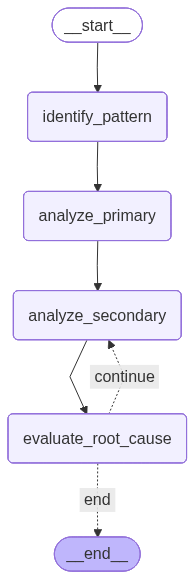

In [21]:
from IPython.display import Image, display

# After creating your graph (app = workflow.compile())
display(Image(create_root_cause_workflow().get_graph().draw_mermaid_png()))

In [12]:
def run_root_cause_analysis(question: str, max_iterations: int = 5):
    """Run the complete root cause analysis workflow"""
    initial_state = RootCauseState(
        question=question,
        current_findings="",
        iteration_count=0,
        max_iterations=max_iterations,
        root_cause_found=False,
        root_cause="",
        primary_data_insights=[],
        secondary_data_insights=[],
        analysis_path=[],
        executed_code_results=[]
    )
    
    workflow = create_root_cause_workflow()
    final_state = workflow.invoke(initial_state)
    return final_state


In [13]:
if __name__ == "__main__":
    question = "How is the revenue from 2011 Nov to 2012 Jan?"
    result = run_root_cause_analysis(question, max_iterations=3)
    
    print("="*50)
    print("ROOT CAUSE ANALYSIS COMPLETE")
    print("="*50)
    print(f"Question: {result['question']}")
    print(f"Analysis Path: {' -> '.join(result['analysis_path'])}")
    print(f"Iterations: {result['iteration_count']}")
    print(f"Root Cause Found: {result['root_cause_found']}")
    print(f"\nRoot Cause: {result['root_cause']}")
    print("\nAll Code Execution Results:")
    for i, result_text in enumerate(result['executed_code_results'], 1):
        print(f"\n--- Execution {i} ---")
        print(result_text)
    print("="*50)

ROOT CAUSE ANALYSIS COMPLETE
Question: How is the revenue from 2011 Nov to 2012 Jan?
Analysis Path: Pattern identified and code executed -> Primary data analyzed with code execution -> Secondary data analyzed with code execution (iteration 1) -> Secondary data analyzed with code execution (iteration 2)
Iterations: 3
Root Cause Found: False

Root Cause: 

All Code Execution Results:

--- Execution 1 ---
Pattern Analysis Code Results:
Execution error: __import__ not found

--- Execution 2 ---
Primary Analysis Code Results:
Execution error: __import__ not found

--- Execution 3 ---
Secondary Analysis Code Results (Iteration 1):
Execution error: __import__ not found

--- Execution 4 ---
Secondary Analysis Code Results (Iteration 2):
Execution error: __import__ not found
